In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import numpy as np
from catboost import CatBoostClassifier
import warnings
from sklearn.preprocessing import TargetEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
warnings.filterwarnings('ignore')
import category_encoders as ce
from pytabkit import RealMLP_TD_Classifier
from gplearn.genetic import SymbolicTransformer
import torch
import torch
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
import logging


# Data Processing

In [3]:
df = pd.read_csv("Data/cardio_train.csv",sep=";")
df.head(5)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
df = df.drop(columns=['id'])

In [5]:
df.shape

(70000, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  int64  
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.4 MB


In [7]:
df.sample(1)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
43537,22609,2,172,93.0,120,80,1,1,0,0,1,1


In [8]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
df.duplicated().sum()

np.int64(24)

In [10]:
dtypes = {
    "age":         "int32",  
    "gender":      "int8",    
    "height":      "int16",  
    "weight":      "float32",  
    "ap_hi":       "int16",    
    "ap_lo":       "int16",    
    "cholesterol": "int8",    
    "gluc":        "int8",    
    "smoke":       "int8",    
    "alco":        "int8",    
    "active":      "int8",    
    "cardio":      "int8",    
}

df = df.astype(dtypes)

print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

age              int32
gender            int8
height           int16
weight         float32
ap_hi            int16
ap_lo            int16
cholesterol       int8
gluc              int8
smoke             int8
alco              int8
active            int8
cardio            int8
dtype: object

Memory usage: 1.47 MB


Memory reduced -> 6.4 MB to 1.47 MB

# EDA

In [11]:
df.head(5)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [12]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205688,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


age ---------->
age--> has 8076 unique elements


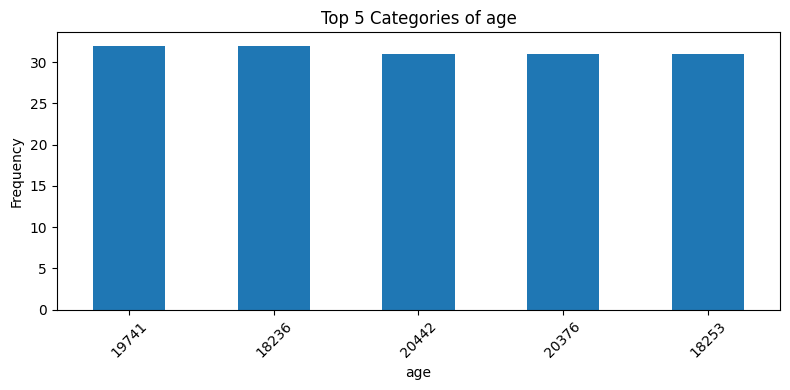

gender ---------->
gender--> has 2 unique elements


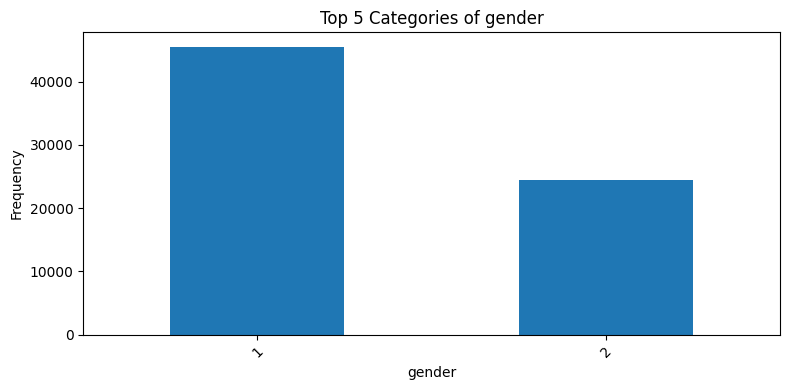

height ---------->
height--> has 109 unique elements


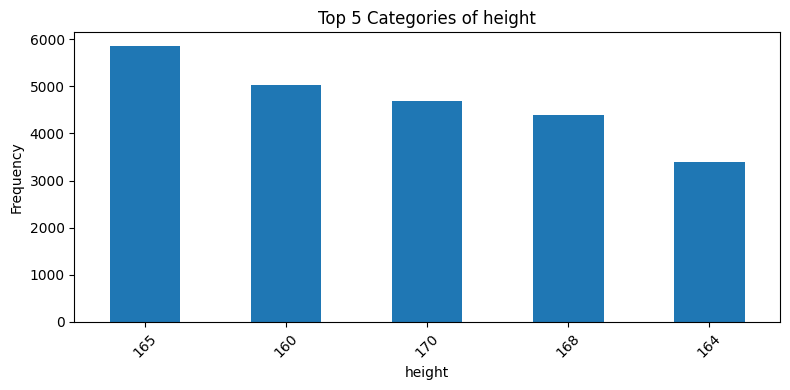

weight ---------->
weight--> has 287 unique elements


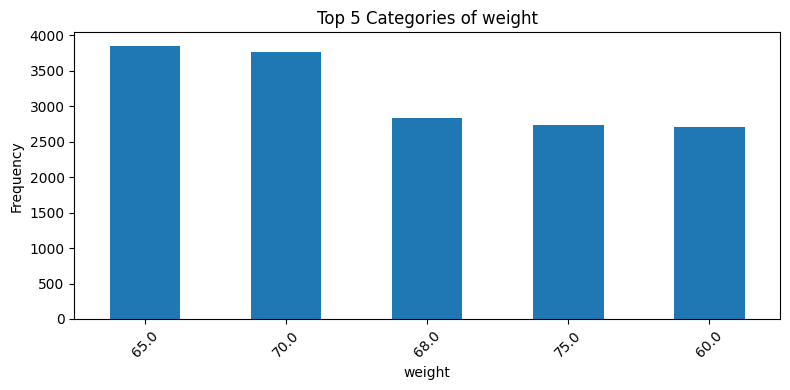

ap_hi ---------->
ap_hi--> has 153 unique elements


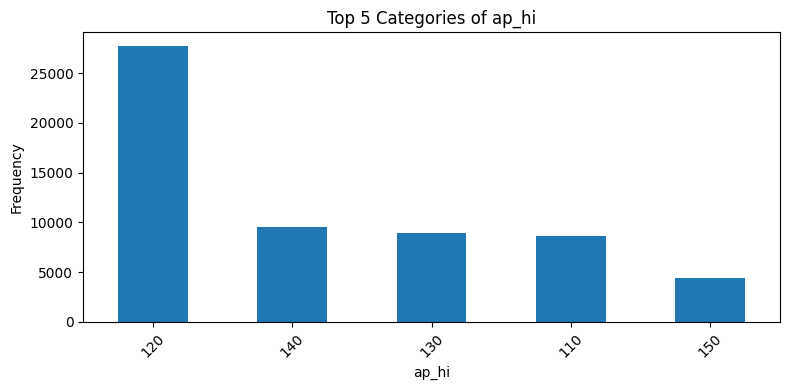

ap_lo ---------->
ap_lo--> has 157 unique elements


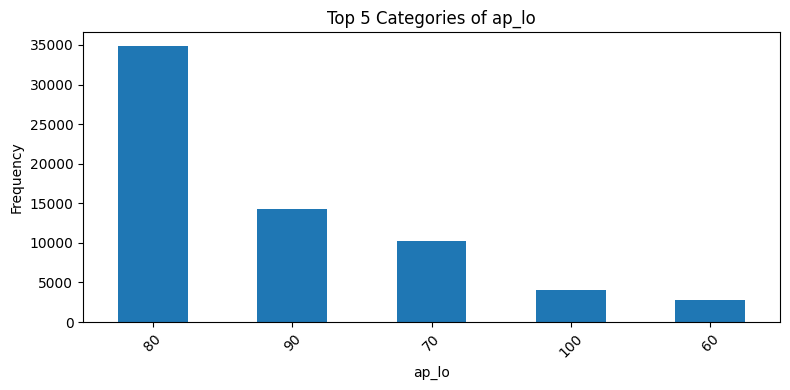

cholesterol ---------->
cholesterol--> has 3 unique elements


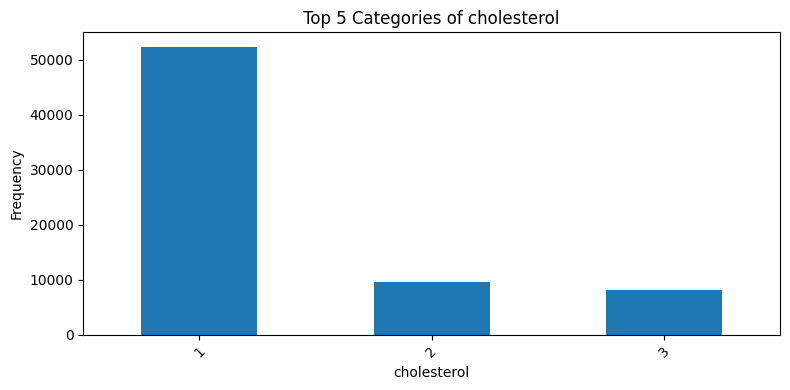

gluc ---------->
gluc--> has 3 unique elements


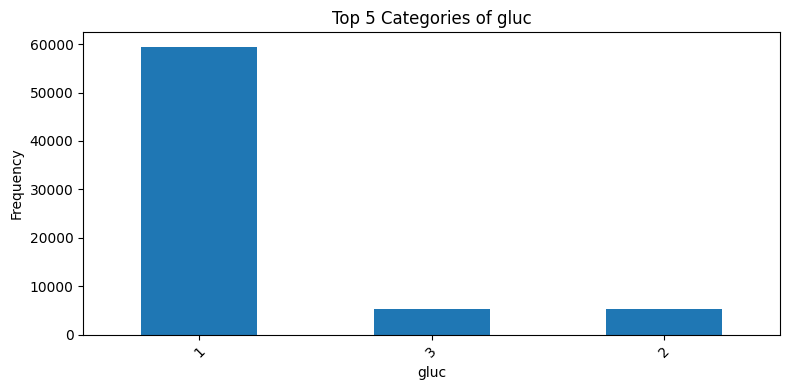

smoke ---------->
smoke--> has 2 unique elements


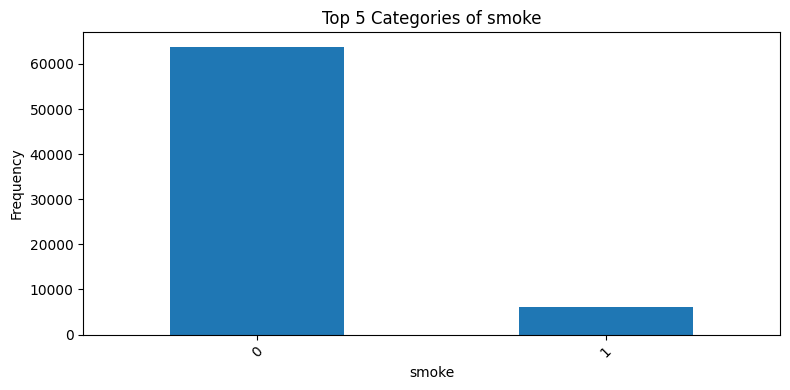

alco ---------->
alco--> has 2 unique elements


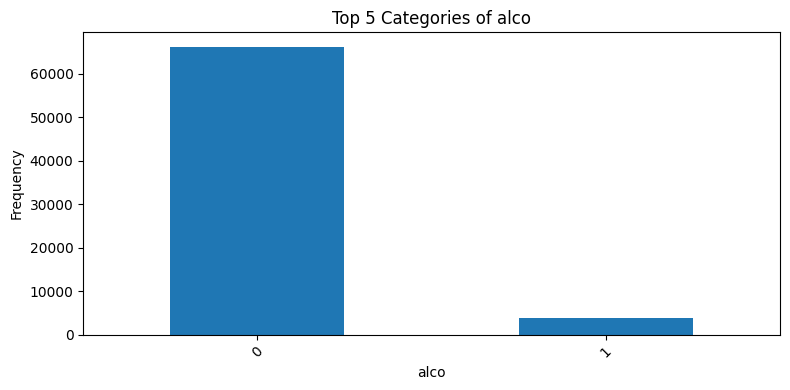

active ---------->
active--> has 2 unique elements


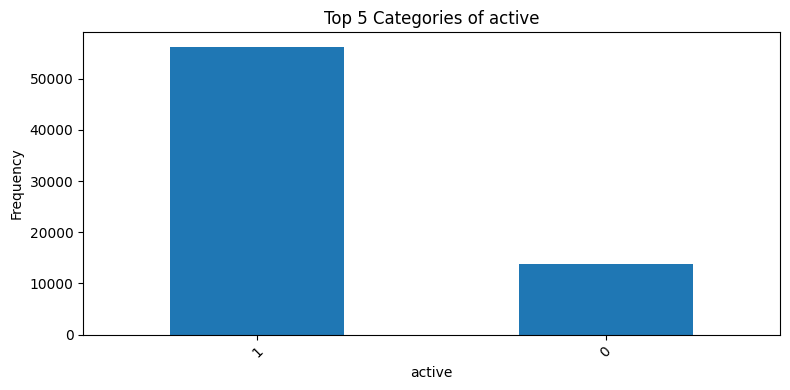

cardio ---------->
cardio--> has 2 unique elements


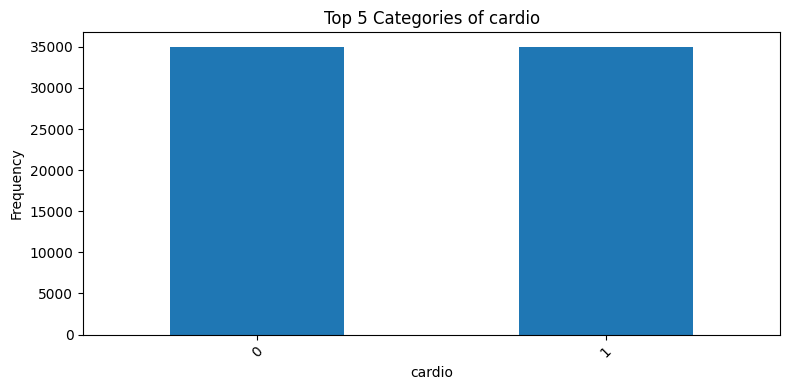

In [13]:
for col in df.columns:
    print(col + " ---------->")
    
    vc = df[col].value_counts().head(5)
    vc.plot(kind="bar", figsize=(8,4))
    
    print(f'{col}--> has {df[col].nunique()} unique elements')

    plt.title(f"Top 5 Categories of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

The dataset is also unbalanced

age ---------->


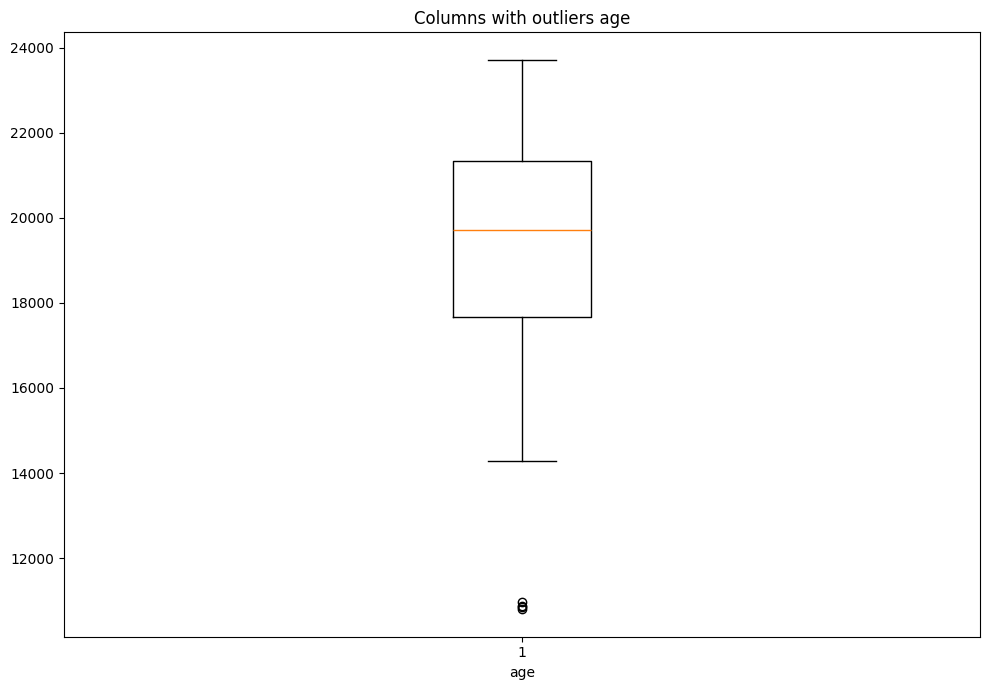

gender ---------->


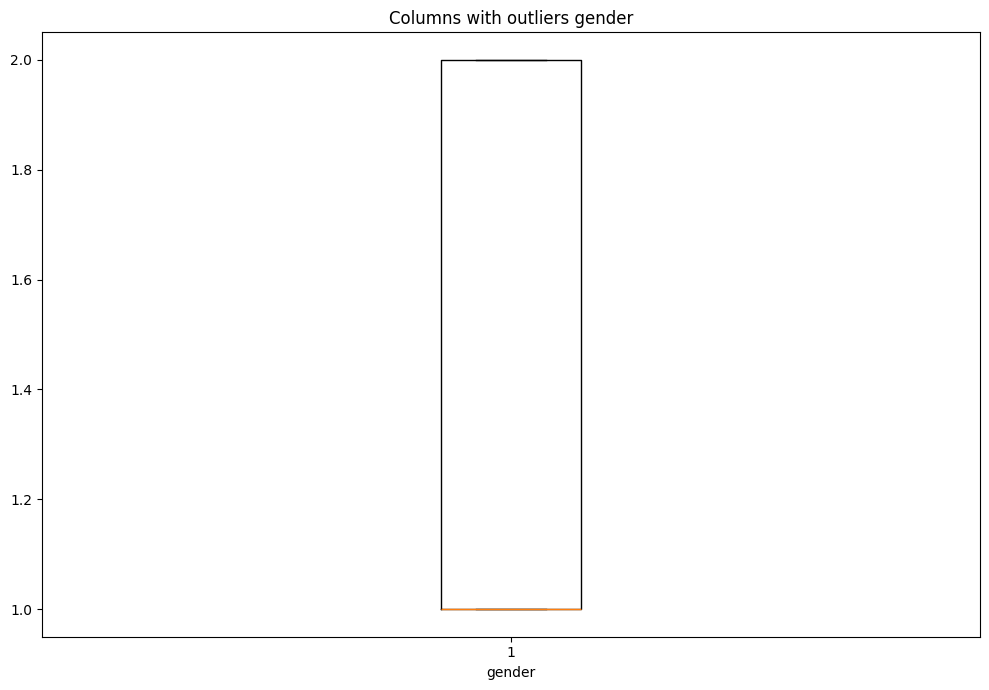

height ---------->


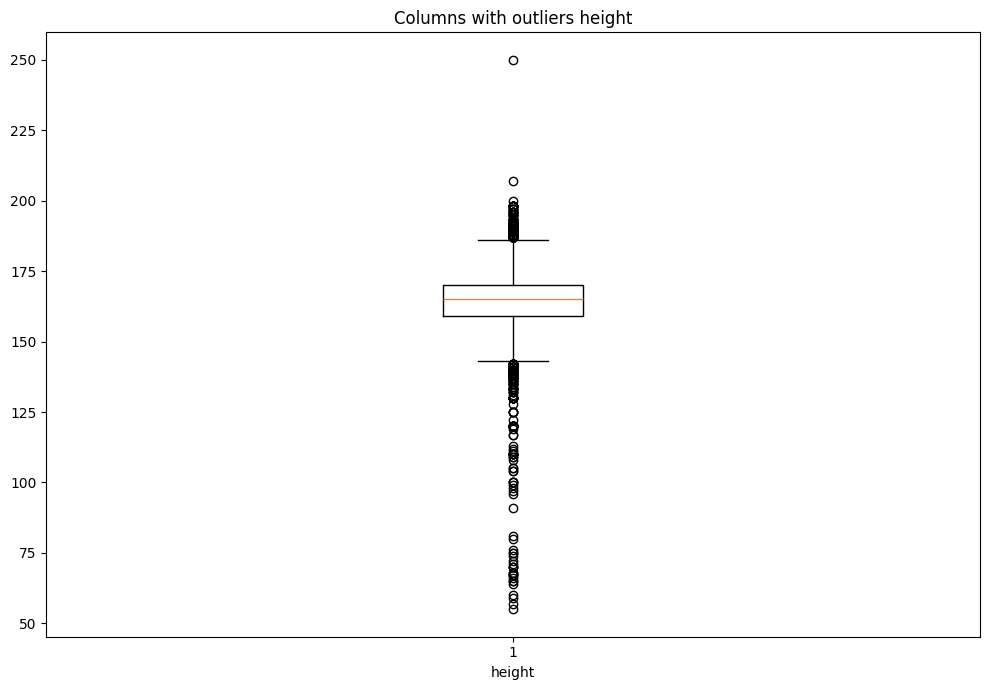

weight ---------->


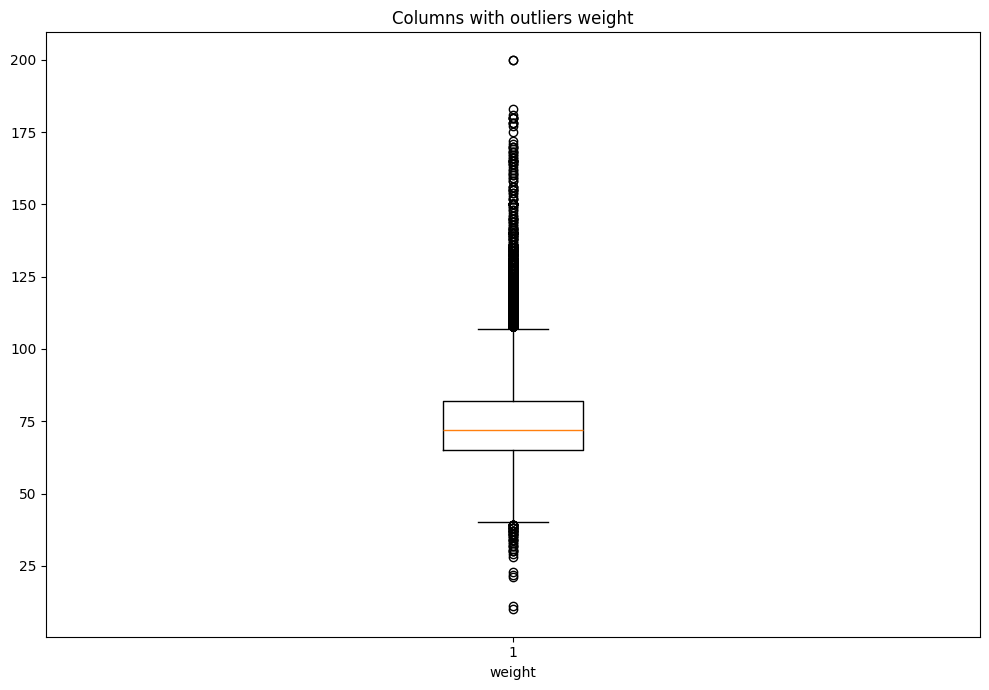

ap_hi ---------->


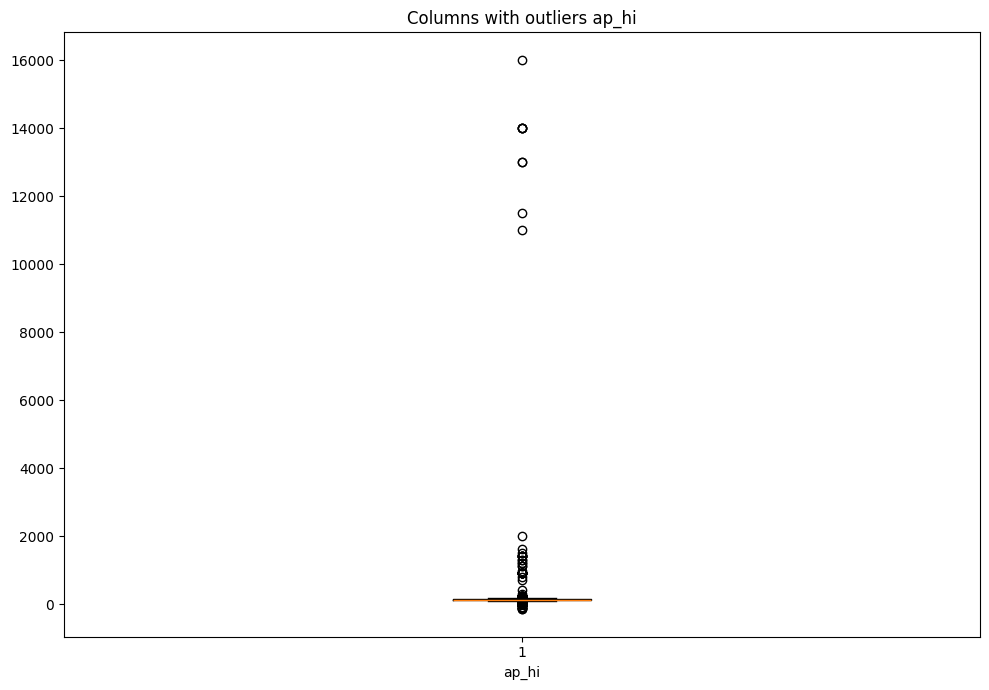

ap_lo ---------->


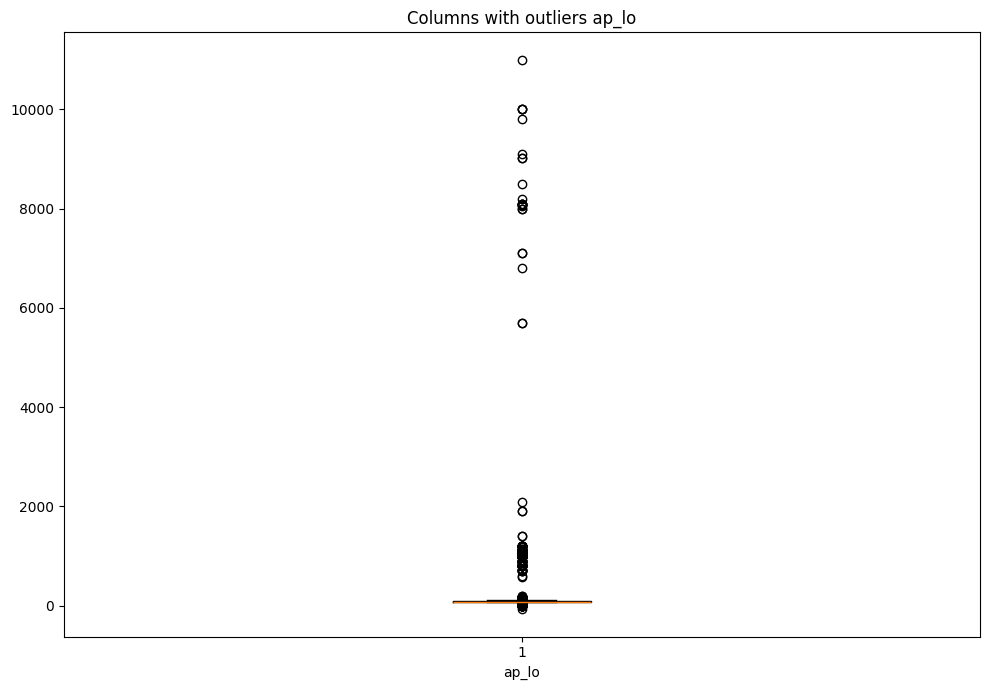

cholesterol ---------->


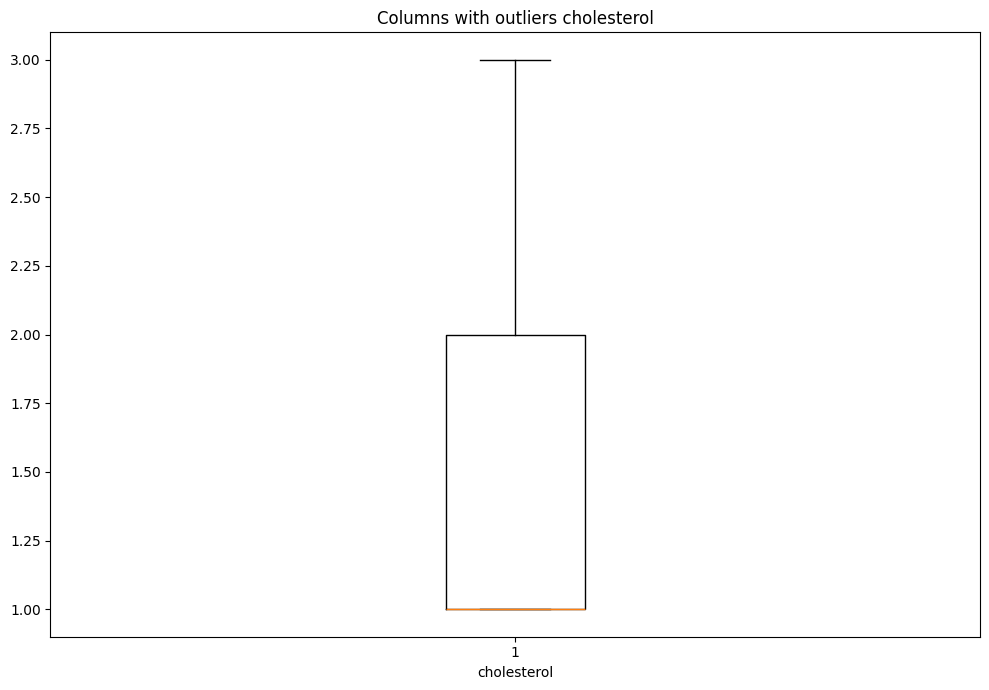

gluc ---------->


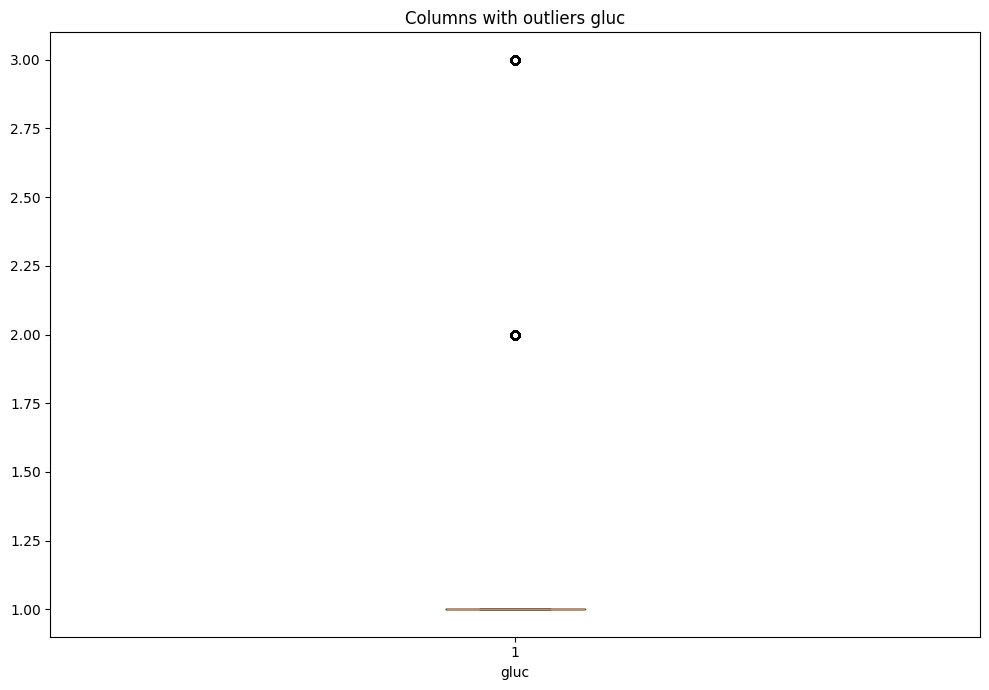

smoke ---------->


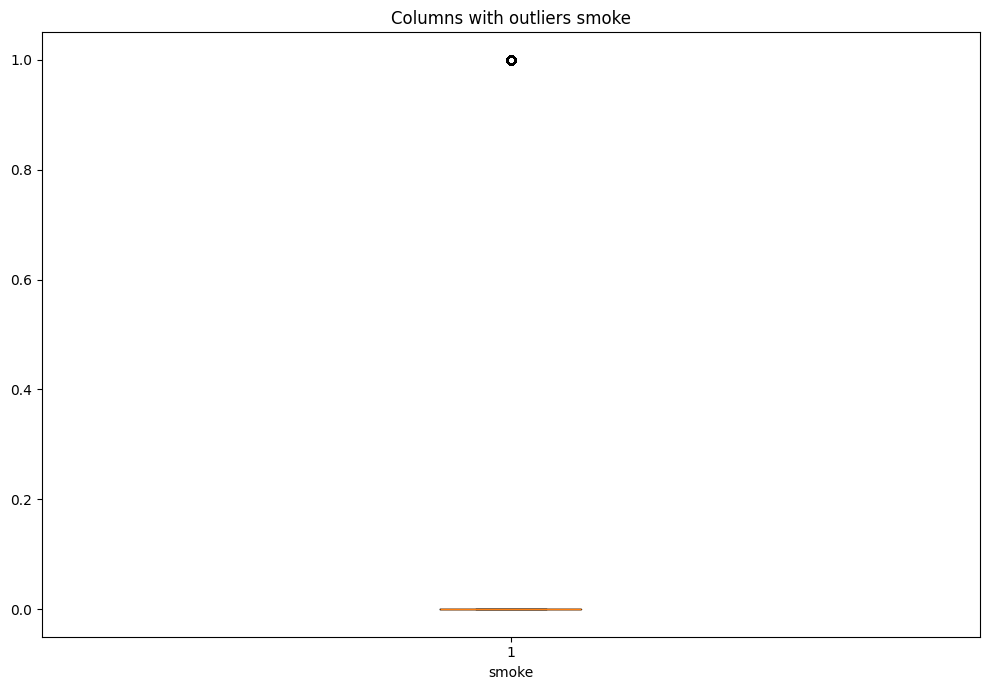

alco ---------->


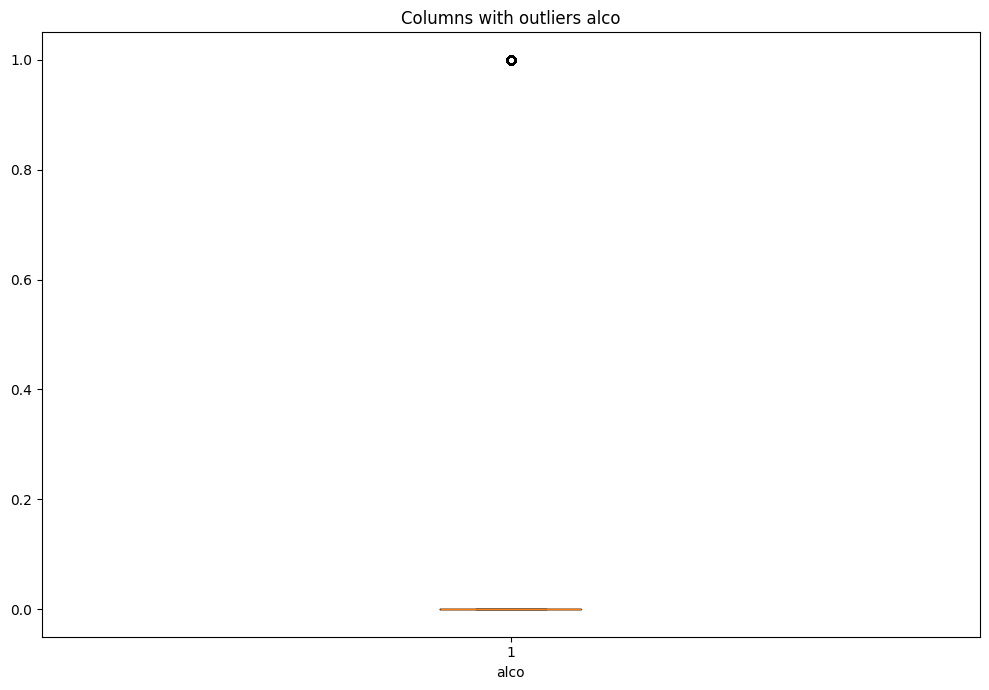

active ---------->


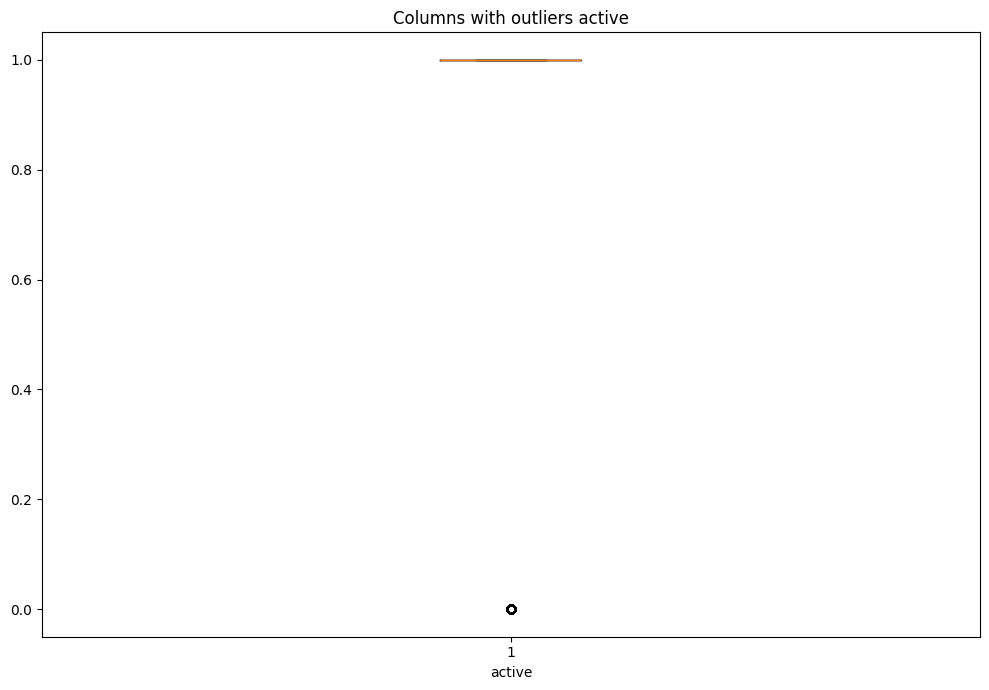

cardio ---------->


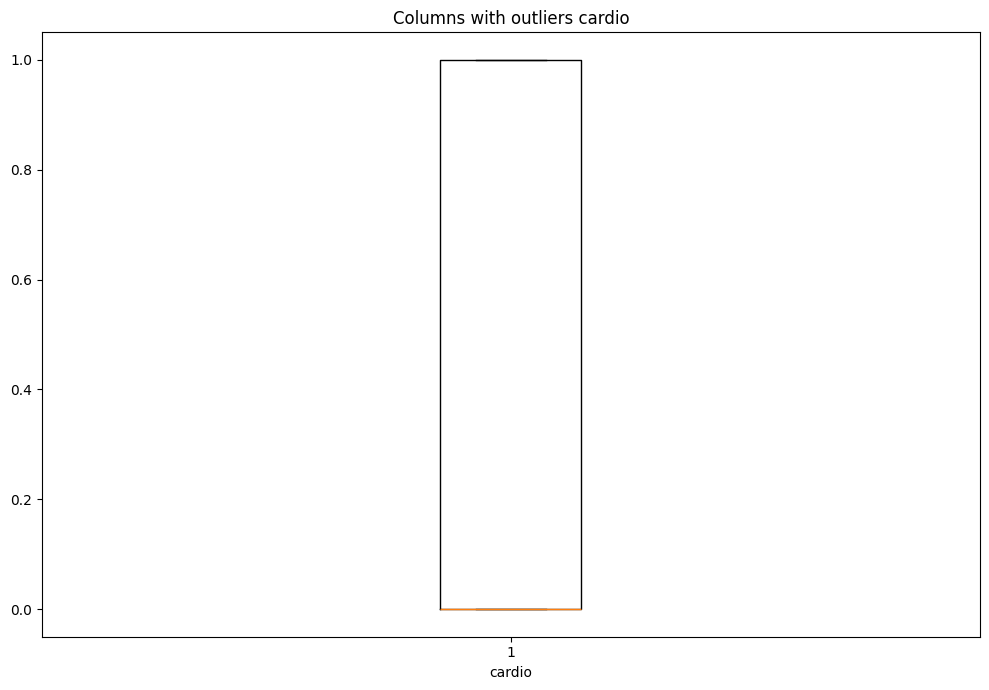

In [14]:
for col in df.columns:
    print(col + " ---------->")
    
    plt.figure(figsize =(10, 7))
    plt.boxplot(df[col])

    plt.title(f"Columns with outliers {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

Columns with outliers are height, weight, ap_hi, ap_lo

age: Skewness = -0.2847 → Roughly Symmetric


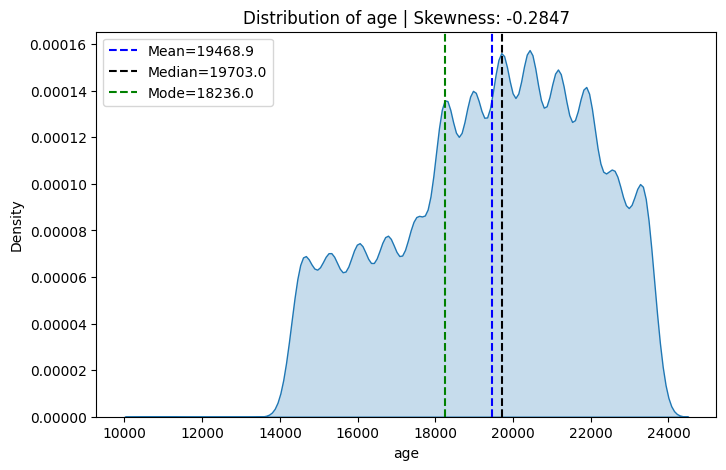

height: Skewness = -0.2341 → Roughly Symmetric


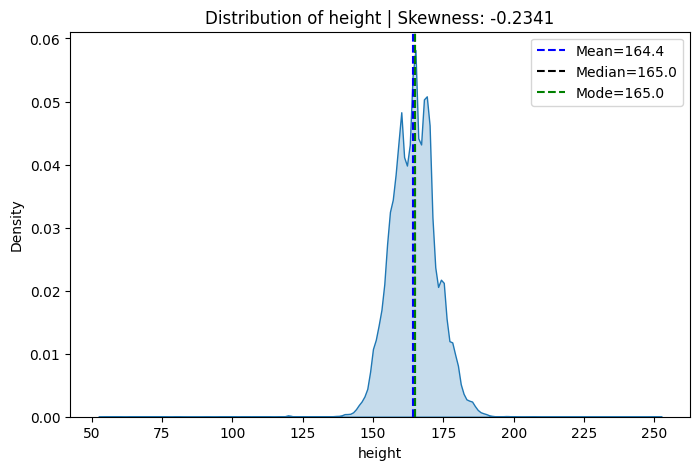

weight: Skewness = 0.4597 → Roughly Symmetric


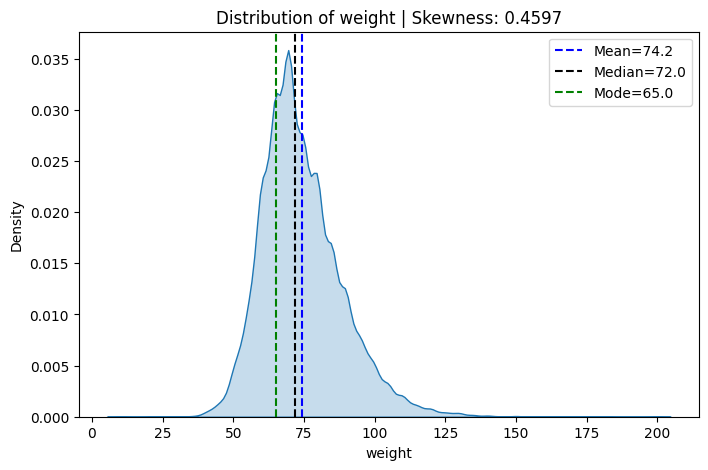

ap_hi: Skewness = 0.1718 → Roughly Symmetric


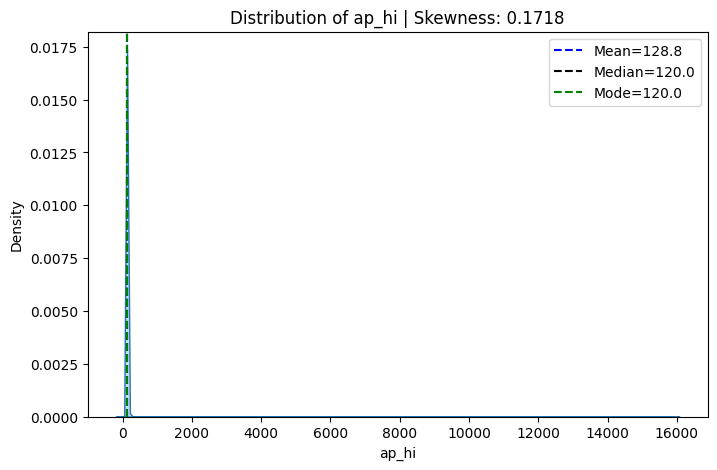

ap_lo: Skewness = 0.2647 → Roughly Symmetric


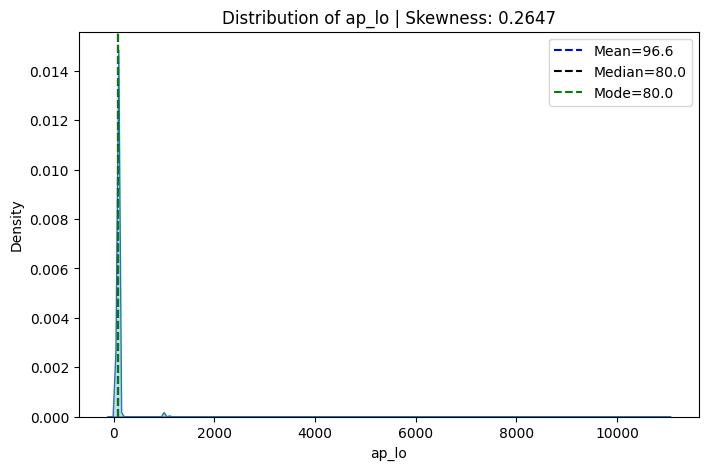

In [15]:
numerical_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

for col in numerical_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    std_val = df[col].std()
    mode_val = df[col].mode()[0]

    pearson_skewness = (3 * (mean_val - median_val)) / std_val

    if pearson_skewness > 0.5:
        skew_type = "Positively Skewed"
    elif pearson_skewness < -0.5:
        skew_type = "Negatively Skewed"
    else:
        skew_type = "Roughly Symmetric"

    print(f"{col}: Skewness = {pearson_skewness:.4f} → {skew_type}")

    plt.figure(figsize=(8, 5))
    sns.kdeplot(df[col], fill=True)
    plt.axvline(mean_val, color='blue', linestyle='--', label=f"Mean={mean_val:.1f}")
    plt.axvline(median_val, color='black', linestyle='--', label=f"Median={median_val:.1f}")
    plt.axvline(mode_val, color='green', linestyle='--', label=f"Mode={mode_val:.1f}")
    plt.title(f"Distribution of {col} | Skewness: {pearson_skewness:.4f}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

This dataset does have outliers

# Preprocess Data

In [16]:
#Removing Outliers
df = df[df['age'] >= 0.06]
df = df[df['ap_hi'].between(80, 180)]
df = df[df['ap_lo'].between(60, 120)]
df = df[df['weight'].between(45, 105)]
df = df[df['ap_hi'] > df['ap_lo']]
df = df[df['height'].between(145, 190)]

In [17]:
df = df.drop_duplicates()

# Feature Engineering

In [18]:
#Save version
train_ver1 = df.copy()

In [19]:
df[['age', 'height', 'weight', 'ap_hi', 'ap_lo']].describe()

,age,height,weight,ap_hi,ap_lo
count,65663.000000,65663.000000,65663.000000,65663.000000,65663.000000
mean,19460.910848,164.434857,73.011070,126.131094,81.118179
std,2466.798926,7.568397,12.114837,15.814827,9.073609
min,10798.000000,145.000000,45.000000,80.000000,60.000000
25%,17657.000000,159.000000,65.000000,120.000000,80.000000
50%,19699.000000,165.000000,71.000000,120.000000,80.000000
75%,21319.000000,170.000000,80.000000,140.000000,90.000000
max,23713.000000,190.000000,105.000000,180.000000,120.000000


In [20]:
##Saving another version
train_df2 = df.copy()

In [21]:
train_df2['age_band']    = pd.qcut(train_df2['age'], q=4, labels=['young','mid_age','senior','elderly'])
train_df2['weight_band'] = pd.qcut(train_df2['weight'], q=4, labels=['light','medium','heavy','very_heavy'])

train_df2['height_band'] = pd.cut(train_df2['height'], bins=[145,155,165,175,190], labels=['very_short','short','medium','tall'])
train_df2['ap_hi_band']  = pd.cut(train_df2['ap_hi'], bins=[80,120,130,140,180], labels=['normal','elevated','high_1','high_2'])
train_df2['ap_lo_band']  = pd.cut(train_df2['ap_lo'], bins=[60,80,90,120], labels=['normal','high_1','high_2'])
train_df2 = train_df2.drop(columns=['age','height','weight','ap_hi','ap_lo'])

In [22]:
train_df3 = df.copy()

In [23]:
# %   → gives the remainder
# //  → gives the quotient (integer division)

train_df3['ap_hi_hundreds'] = (train_df3['ap_hi'] // 100).astype(int)
train_df3['ap_hi_tens']     = (train_df3['ap_hi'] % 100 // 10).astype(int)
train_df3['ap_hi_units']    = (train_df3['ap_hi'] % 10).astype(int)

# AP_LO digits (values like 60-120)
train_df3['ap_lo_hundreds'] = (train_df3['ap_lo'] // 100).astype(int)
train_df3['ap_lo_tens']     = (train_df3['ap_lo'] % 100 // 10).astype(int)
train_df3['ap_lo_units']    = (train_df3['ap_lo'] % 10).astype(int)

# Height digits (values like 145-190)
train_df3['height_hundreds'] = (train_df3['height'] // 100).astype(int)
train_df3['height_tens']     = (train_df3['height'] % 100 // 10).astype(int)
train_df3['height_units']    = (train_df3['height'] % 10).astype(int)

# Weight digits (values like 45-105)
train_df3['weight_tens']  = (train_df3['weight'] // 10).astype(int)
train_df3['weight_units'] = (train_df3['weight'] % 10).astype(int)

train_df3['age_d1'] = (train_df3['age'] * 10).astype(int) % 10  
train_df3['age_d2'] = (train_df3['age'] * 100).astype(int) % 10 


In [24]:
train_df4 = train_df3.copy()

In [25]:
train_df4 = train_df3.astype(str).astype('category')

In [26]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [27]:
X = df.drop("cardio", axis=1)   # features
y = df["cardio"]                # label

In [28]:
#Baseline prediction

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = XGBClassifier()

model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, predictions)
print('y_test:', y_test)
print('predictions:', predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")

y_test: 69271    1
8894     1
16202    0
64267    0
36972    1
        ..
40764    0
28467    1
12180    0
38814    0
33518    1
Name: cardio, Length: 13133, dtype: int8
predictions: [1 1 0 ... 0 0 0]
Accuracy: 73.08%


In [29]:
# Encode
cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
encoder = ce.TargetEncoder(cols=cat_cols)
encoder.fit(X_train, y_train)

# Transform both
X_train_encoded = encoder.transform(X_train)
X_test_encoded  = encoder.transform(X_test)

# Reconstruct full df with target column
train_df5 = pd.concat([
    pd.concat([X_train_encoded, y_train], axis=1),
    pd.concat([X_test_encoded, y_test], axis=1)
]).sort_index() 

In [30]:
train_df5 = df.copy()


num_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

function_set = ['add', 'sub', 'mul', 'div', 'sqrt', 'log', 'abs']

gp = SymbolicTransformer(
    generations=5,          # how many evolution rounds
    population_size=1000,   # how many candidates per round
    hall_of_fame=100,       # top candidates kept
    n_components=10,        # number of new features to create
    function_set=function_set,
    parsimony_coefficient=0.001,
    max_samples=0.9,
    random_state=42,
    verbose=1,
    n_jobs=-1               # use all CPU cores
)

gp.fit(X[num_cols], y)
gp_features = gp.transform(X[num_cols])

# Add new features to df
gp_df = pd.DataFrame(
    gp_features,
    columns=[f'gp_{i}' for i in range(gp_features.shape[1])],
    index=X.index
)

train_df5 = pd.concat([train_df5, gp_df], axis=1)

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    12.61          0.22793       39         0.449337         0.453337     10.77s
   1     6.91         0.382574       14         0.457085         0.445887      2.91s
   2     5.21         0.403224       19         0.458913         0.454232      2.13s
   3     8.35         0.404939       13         0.460023         0.443762      1.03s
   4     6.50         0.395347       10         0.460634         0.435039      0.00s


# Model Training

In [31]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Model params ──────────────────────────────────────
xgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'auc',
    'random_state': 42,
    'verbosity': 0
}

lgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'verbose': -1
}
realmlp_params = {
    'device': 'cuda',
    'random_state': 42,
    'n_epochs': 100,
    'batch_size': 128,
    'n_ens': 8,
    'val_metric_name': '1-auc_ovr',
    'use_early_stopping': True,
    'early_stopping_additive_patience': 20,
    'early_stopping_multiplicative_patience': 1,
    'act': "mish",
    'embedding_size': 8,
    'first_layer_lr_factor': 0.5962121993798933,
    'hidden_sizes': "rectangular",
    'hidden_width': 384,
    'lr': 0.04,
    'ls_eps': 0.011498317194338772,
    'ls_eps_sched': "coslog4",
    'max_one_hot_cat_size': 18,
    'n_hidden_layers': 4,
    'p_drop': 0.07301419697186451,
    'p_drop_sched': "flat_cos",
    'plr_hidden_1': 16,
    'plr_hidden_2': 8,
    'plr_lr_factor': 0.1151437622270563,
    'plr_sigma': 2.3316811282666916,
    'scale_lr_factor': 2.244801835541429,
    'sq_mom': 1.0 - 0.011834054955582318,
    'wd': 0.02369230879235962,
}


# ── OOF functions ─────────────────────────────────────
def train_oof_xgb(X, y, params, skf):
    # XGBoost cant handle category dtype → convert to int
    X = X.copy()
    cat_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()
    for col in cat_cols:
        X[col] = X[col].cat.codes

    oof_preds = np.zeros(len(y))
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model = XGBClassifier(**params)
        model.fit(X_train, y_train)
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y, oof_preds)
    return oof_preds, auc


def train_oof_lgb(X, y, params, skf):
    # LightGBM handles category dtype natively ✅
    oof_preds = np.zeros(len(y))
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model = LGBMClassifier(**params)
        model.fit(X_train, y_train)
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y, oof_preds)
    return oof_preds, auc


def train_oof_realmlp(X, y, params, skf):
    # RealMLP cant handle category dtype → convert to int
    X = X.copy()
    cat_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()
    for col in cat_cols:
        X[col] = X[col].cat.codes

    oof_preds = np.zeros(len(y))
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model = RealMLP_TD_Classifier(**params)
        model.fit(X_train, y_train)
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y, oof_preds)
    return oof_preds, auc


# ── Main training function ────────────────────────────
def train_all_versions(version_dict):
    results = {}

    for version_name, data in version_dict.items():
        print(f'\n{"="*50}')
        print(f'  Version: {version_name}')
        print(f'{"="*50}')

        X = data.drop(columns=['cardio'])
        y = data['cardio'].astype(int) 

        # XGBoost
        print(f'XGBoost → training...')
        _, auc = train_oof_xgb(X, y, xgb_params, skf)
        results[f'{version_name}_xgb'] = auc
        print(f'XGBoost → AUC: {auc:.6f}')

        # LightGBM
        print(f'LightGBM → training...')
        _, auc = train_oof_lgb(X, y, lgb_params, skf)
        results[f'{version_name}_lgb'] = auc
        print(f'LightGBM → AUC: {auc:.6f}')

        # RealMLP
        print(f'RealMLP → training...')
        _, auc = train_oof_realmlp(X, y, realmlp_params, skf)
        results[f'{version_name}_realmlp'] = auc
        print(f'RealMLP → AUC: {auc:.6f}')

    # ── Summary ──────────────────────────────────────
    print(f'\n\n{"="*50}')
    print('FINAL SUMMARY')
    print(f'{"="*50}')
    results_df = pd.DataFrame(
        list(results.items()),
        columns=['Model_Version', 'AUC']
    ).sort_values('AUC', ascending=False)

    print(results_df.to_string(index=False))
    return results_df


# ── Run ───────────────────────────────────────────────
versions = {
    'v1': train_ver1,
    'v2': train_df2,
    'v3': train_df3,
    'v4': train_df4,
    'v5': train_df5,
}

results_df = train_all_versions(versions)


  Version: v1
XGBoost → training...
XGBoost → AUC: 0.791993
LightGBM → training...
LightGBM → AUC: 0.794456
RealMLP → training...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to

RealMLP → AUC: 0.799627

  Version: v2
XGBoost → training...
XGBoost → AUC: 0.786189
LightGBM → training...
LightGBM → AUC: 0.788649
RealMLP → training...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experime

RealMLP → AUC: 0.793150

  Version: v3
XGBoost → training...
XGBoost → AUC: 0.790117
LightGBM → training...
LightGBM → AUC: 0.793777
RealMLP → training...


...

RealMLP → AUC: 0.800336

  Version: v4
XGBoost → training...
XGBoost → AUC: 0.790243
LightGBM → training...
LightGBM → AUC: 0.766690
RealMLP → training...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experime

RealMLP → AUC: 0.799958

  Version: v5
XGBoost → training...
XGBoost → AUC: 0.791235
LightGBM → training...
LightGBM → AUC: 0.793528
RealMLP → training...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experime

RealMLP → AUC: 0.799828


FINAL SUMMARY
Model_Version      AUC
   v3_realmlp 0.800336
   v4_realmlp 0.799958
   v5_realmlp 0.799828
   v1_realmlp 0.799627
       v1_lgb 0.794456
       v3_lgb 0.793777
       v5_lgb 0.793528
   v2_realmlp 0.793150
       v1_xgb 0.791993
       v5_xgb 0.791235
       v4_xgb 0.790243
       v3_xgb 0.790117
       v2_lgb 0.788649
       v2_xgb 0.786189
       v4_lgb 0.766690


In [52]:
import pickle

# Save the best model — V1 RealMLP
# First train it on full data
X = train_df3.drop(columns=['cardio'])
y = train_df3['cardio'].astype(int)

best_model = RealMLP_TD_Classifier(**realmlp_params)
best_model.fit(X, y)

# Save model 
with open('best_model_v1_realmlp.pkl', 'wb') as f:
    pickle.dump(best_model, f)


# Save the data versions too
train_ver1.to_csv('train_v1.csv', index=False)

print('All saved!')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


All saved!


In [53]:
import pickle
# Load model
with open('best_model_v1_realmlp.pkl', 'rb') as f:
    best_model = pickle.load(f)

print('Loaded successfully!')

Loaded successfully!


Baseline Model (Accuracy) = 0.73

It imporved from 0.73 to 0.80 which is huge and good so now imporve that model to get maybe more score

In [42]:
import optuna

In [43]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        # FIXED 
        'device':                                 'cuda',
        'random_state':                           42,
        'val_metric_name':                        '1-auc_ovr',
        'use_early_stopping':                     True,
        'early_stopping_additive_patience':       20,
        'early_stopping_multiplicative_patience': 1,
        'act':                                    'mish',
        'ls_eps':                                 0.011498317194338772,
        'ls_eps_sched':                           'coslog4',
        'p_drop_sched':                           'flat_cos',
        'hidden_sizes':                           'rectangular',

        # TUNE 
        'lr':              trial.suggest_float('lr', 0.01, 0.1, log=True),
        'embedding_size':  trial.suggest_int('embedding_size', 7, 9),
        'hidden_width':    trial.suggest_int('hidden_width', 256, 512),  # ← merged both into one range
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 2, 6),
        'p_drop':          trial.suggest_float('p_drop', 0.0, 0.3),
        'batch_size':      trial.suggest_categorical('batch_size', [64, 128, 256]),
        'wd':              trial.suggest_float('wd', 0.001, 0.1, log=True),
        'n_ens':           trial.suggest_categorical('n_ens', [4, 8, 16]),
        'n_epochs':        trial.suggest_int('n_epochs', 50, 200),
    }

    oof_preds = np.zeros(len(y))

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = RealMLP_TD_Classifier(**params)
        model.fit(X_train, y_train)
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

    return roc_auc_score(y, oof_preds)


# Run Optuna 
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

# Results 
print(f'Best AUC:    {study.best_value:.6f}')
print(f'Baseline:    0.800034')
print(f'Improvement: {study.best_value - 0.800034:+.6f}')
print(f'\nBest params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

[I 2026-03-12 16:59:24,210] A new study created in memory with name: no-name-e3f15817-4daf-4a16-b00c-1be76c64d25d


  0%|          | 0/50 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experime

[I 2026-03-12 17:09:11,496] Trial 0 finished with value: 0.7991538746174202 and parameters: {'lr': 0.07337469943745908, 'embedding_size': 8, 'hidden_width': 374, 'n_hidden_layers': 2, 'p_drop': 0.22666076508215613, 'batch_size': 64, 'wd': 0.003011983482845704, 'n_ens': 8, 'n_epochs': 173}. Best is trial 0 with value: 0.7991538746174202.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experime

...

[I 2026-03-12 17:19:59,025] Trial 2 finished with value: 0.799779178774429 and parameters: {'lr': 0.01363201909836835, 'embedding_size': 8, 'hidden_width': 350, 'n_hidden_layers': 4, 'p_drop': 0.01046880493624922, 'batch_size': 256, 'wd': 0.008319464196940915, 'n_ens': 16, 'n_epochs': 101}. Best is trial 2 with value: 0.799779178774429.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experime

[I 2026-03-12 17:30:44,358] Trial 3 finished with value: 0.7993363300683941 and parameters: {'lr': 0.0434524504348191, 'embedding_size': 9, 'hidden_width': 432, 'n_hidden_layers': 4, 'p_drop': 0.12487935157728441, 'batch_size': 64, 'wd': 0.0010298299682291476, 'n_ens': 4, 'n_epochs': 123}. Best is trial 2 with value: 0.799779178774429.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experime

SystemExit: 1

As we can see, hyperparameter tuning is not improving my model. This is likely because the parameters I used were already tuned and achieved 3rd place in the Kaggle competition, so they may not improve further.

In [54]:
import pickle
# Load model
with open('best_model_v1_realmlp.pkl', 'rb') as f:
    model = pickle.load(f)

print('Loaded successfully!')

Loaded successfully!


In [55]:
#Exlainable AI
import shap

In [56]:
X = train_df3.drop(columns=['cardio'])
y = train_df3['cardio'].astype(int)

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  0%|          | 0/50 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experime

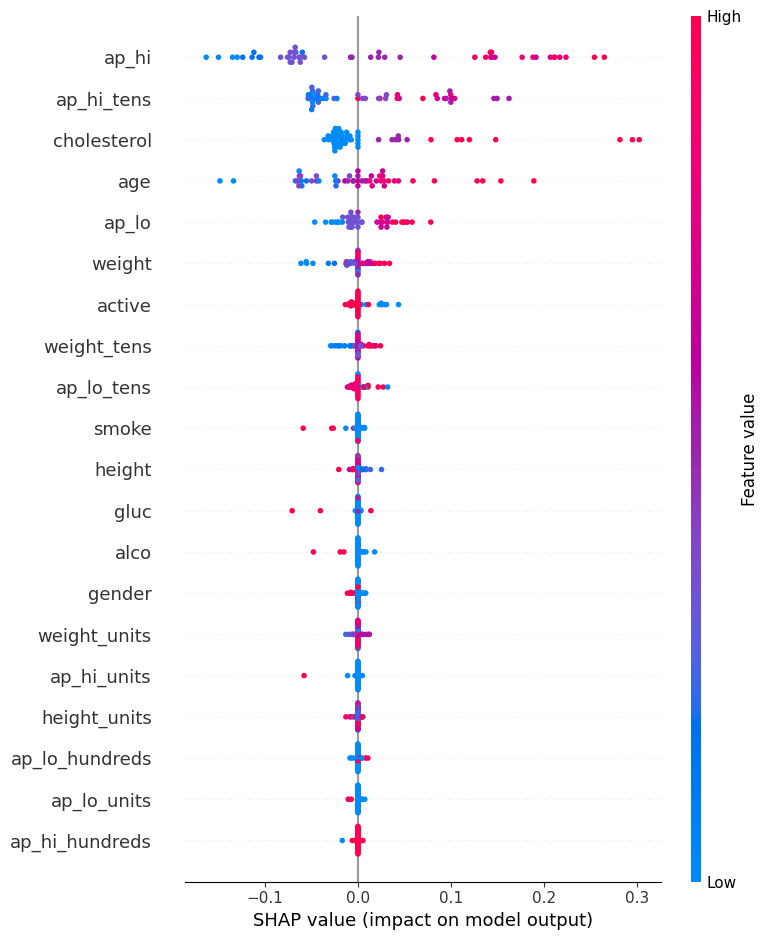

In [58]:
def model_predict(data):
    df_input = pd.DataFrame(data, columns=X_test.columns)
    return model.predict_proba(df_input)[:, 1]

background = shap.sample(X_test, 50)
test_sample = X_test.iloc[:50]

explainer = shap.KernelExplainer(model_predict, background)
shap_values = explainer.shap_values(test_sample, nsamples=100)

# Plot 1 - Summary
shap.summary_plot(shap_values, test_sample)

In [59]:
explainer = shap.KernelExplainer(
    lambda x: model.predict_proba(pd.DataFrame(x, columns=X_test.columns))[:, 1],
    shap.sample(X_test, 50)
)

shap_vals = explainer.shap_values(X_test.iloc[:200], nsamples=100)

np.save('shap_values.npy', shap_vals)
X_test.iloc[:200].to_csv('X_test.csv', index=False)
print("Saved!")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  0%|          | 0/200 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experime

Saved!


In [60]:
train_ver1.shape

(65663, 17)

In [66]:
with open('best_model_v1_realmlp.pkl', 'rb') as f:
    model_v3 = pickle.load(f)

model_v3.alg_interface_.device = 'cpu'
model_v3.alg_interface_.to('cpu')

with open('best_model_v1_realmlp.pkl', 'wb') as f:
    pickle.dump(model_v3, f)

X_v3 = train_df3.drop(columns=['cardio'])
_, X_test_v3, _, _ = train_test_split(X_v3, y, test_size=0.2, random_state=42)

explainer = shap.KernelExplainer(
    lambda x: model_v3.predict_proba(pd.DataFrame(x, columns=X_test_v3.columns))[:, 1],
    shap.sample(X_test_v3, 50)
)
shap_vals = explainer.shap_values(X_test_v3.iloc[:200], nsamples=100)
np.save('shap_values.npy', shap_vals)
X_test_v3.iloc[:200].to_csv('X_test.csv', index=False)
print("Done!")

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


  0%|          | 0/200 [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: True (cuda), used: False
TPU available: False, using

Done!
